# Combining Sample and Control Files (qc, blank, env blank) for Contamination Correction

In [1]:
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns

import glob, os
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from difflib import get_close_matches


# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]

# Replace these with  actual QC, env, blank file paths beacuse we want to remove the contamination and get the actual peaks for samples
qc_files    = glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files   = glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files = glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")

all_files = (
    [(f, "sample") for f in sample_files] +
    [(f,    "qc") for f in qc_files] +
    [(f,   "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)

rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
combined = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV
combined.to_csv(output_path, index=False)
print(f"Combined dataset saved to: {output_path}")
combined.head()

Combined dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filtering True Sample Compounds

In [2]:
# Exclude compounds found in blanks,QC and env
exclude = combined.loc[
    combined['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only sample compounds 
real = combined.loc[
    (combined['FileType'] == 'sample') &
    (~combined['Compound Name'].isin(exclude))
].copy()

print("Filtered sample compounds:", real.shape)
real.head()


Filtered sample compounds: (2498, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Checking the presence of known potato aroma compounds

In [3]:
# Reference potato aroma volatiles
potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-"
]

# Normalize names for fuzzy matching
def normalize(name):
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')

ref_norm = { normalize(x): x for x in potato_aromas }

real['norm_name'] = real['Compound Name'].apply(normalize)
real['is_aroma'] = real['norm_name'].isin(ref_norm)

# Fuzzy match for near-misses
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~real['is_aroma']
fuzzy_hits = real.loc[mask, 'norm_name'].map(lambda n: fuzzy_match(n, list(ref_norm)))
real.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
real.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = fuzzy_hits.map(ref_norm)

# Keep only aroma compounds
aroma_samples = real[real['is_aroma']].copy()

# Group by FileName
aroma_per_sample = (
    aroma_samples
    .groupby('FileName')['Compound Name']
    .unique()
    .reset_index(name='Aroma Compounds')
)

aroma_per_sample.head()

,FileName,Aroma Compounds
0,sample_1.csv,"[Butanal, 3-methyl-, Cyclotrisiloxane, hexamet..."
1,sample_10.csv,"[2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ..."
2,sample_11.csv,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."
3,sample_12.csv,"[Butanal, 3-methyl-, Hexanal, Cyclotrisiloxane..."
4,sample_13.csv,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."


# Map variety on samples

In [4]:

# Load the combined compound file and master mapping table
combined = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv")
master = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv")
print(master.columns)
master.head()

# Filter only 'sample' rows
samples = combined[combined['FileType'] == 'sample'].copy()

# Extract sample number from filename 
samples['SampleNumber'] = samples['FileName'].str.extract(r'(\d+)').astype(int)

# Drop rows that are Blank or QC
valid_master = master[~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])].copy()

# Extract sample number from filenames 
valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B')[0].astype(int)

# Extract Variety from the last part of semicolon-separated string
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Drop duplicates 
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge with compound dataset
merged = pd.merge(samples, sample_to_variety, on='SampleNumber', how='left')

# Save final mapped file
merged.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\mapped_samples_with_varieties_complete.csv", index=False)
print(" Mapping complete. File saved as 'mapped_samples_with_varieties_complete.csv'")

print(f"Total rows in merged file: {len(merged)}")
print(f"Unique varieties (including NaN): {len(merged['Variety'].unique())}")
print(f"Unique mapped varieties (non-null): {merged['Variety'].nunique()}")

Index(['#', 'Filename', 'Sample', 'Block', 'Plot', 'Sample_order',
       'Sample_date', 'Rep', 'Day', 'Injection_order', 'Blender', 'Tenax',
       'Remark', 'Scan tenax', 'Check'],
      dtype='object')
 Mapping complete. File saved as 'mapped_samples_with_varieties_complete.csv'
Total rows in merged file: 2498
Unique varieties (including NaN): 94
Unique mapped varieties (non-null): 94


# Use merged for aroma processing

In [5]:
# Work with merged (sample + variety)
samples = merged.copy()

# Keep only aroma compounds
samples['norm_name'] = samples['Compound Name'].apply(lambda x: x.lower().replace(' ', '').replace('-', '').replace(',', ''))
potato_aromas_norm = {x.lower().replace(' ', '').replace('-', '').replace(',', ''): x for x in [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-"
]}

samples['is_aroma'] = samples['norm_name'].isin(potato_aromas_norm)
aroma_samples = samples[samples['is_aroma']].copy()
aroma_samples['Compound Name'] = aroma_samples['norm_name'].map(potato_aromas_norm)

# Group by FileName & Variety
aroma_per_sample = (
    aroma_samples
    .groupby(['FileName', 'Variety'])['Compound Name']
    .unique()
    .reset_index(name='Aroma Compounds')
)
aroma_per_sample.head()


,FileName,Variety,Aroma Compounds
0,sample_1.csv,ADORA,"[Butanal, 3-methyl-, Cyclotrisiloxane, hexamet..."
1,sample_10.csv,ARDECHE,"[2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ..."
2,sample_11.csv,ARGOS,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."
3,sample_12.csv,ARIZONA,"[Butanal, 3-methyl-, Hexanal, Cyclotrisiloxane..."
4,sample_13.csv,ATLANTIC,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."


# building Variety - Compound matrix

In [6]:
# Explode for long format
exploded = aroma_per_sample.explode('Aroma Compounds').dropna(subset=['Aroma Compounds', 'Variety'])

# Build Variety × Aroma Compound matrix
variety_aroma_matrix = pd.crosstab(exploded['Variety'], exploded['Aroma Compounds'])
variety_aroma_matrix.head()

Aroma Compounds,"2-Propanone, 1-methoxy-",Benzaldehyde,"Butanal, 3-methyl-","Cyclotrisiloxane, hexamethyl-",Dimethyl trisulfide,Furfural,Hexanal,Methional,Nonanal,Pentanal
Variety,,,,,,,,,,
ADORA,0,1,1,1,0,0,0,0,1,0
AGRIA,1,1,1,1,1,0,0,0,1,1
ALOUETTE,0,1,1,1,0,0,0,0,1,0
ALTHEA,0,1,1,1,0,0,0,0,1,1
ALTURAS,0,1,1,1,0,0,1,0,1,0


# Counting aroma across each variety

In [7]:
# Count unique aroma compounds per variety
aroma_counts_by_variety = (
    variety_aroma_matrix.sum(axis=1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'Aroma Count', 'Variety': 'Variety'})
)

print("Unique aroma compounds per variety:")
print(aroma_counts_by_variety)

# Count frequency of each compound across varieties
compound_frequency = (
    variety_aroma_matrix.sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'Frequency', 'Aroma Compounds': 'Compound'})
)

print("\nMost frequent aroma compounds across all varieties:")
print(compound_frequency.head(10))


Unique aroma compounds per variety:
           Variety  Aroma Count
0      LADY CLAIRE           10
1        INNOVATOR            9
2    ALVERSTONE R.            8
3           FRISIA            8
4          ARDECHE            7
..             ...          ...
85          OSPREY            3
86  MULBERRYBEAUTY            3
87           SMART            3
88          TAURUS            3
89         TRIPLE7            3

[90 rows x 2 columns]

Most frequent aroma compounds across all varieties:
                        Compound  Frequency
0                   Benzaldehyde         90
1  Cyclotrisiloxane, hexamethyl-         90
2                        Nonanal         90
3             Butanal, 3-methyl-         71
4        2-Propanone, 1-methoxy-         46
5            Dimethyl trisulfide         44
6                        Hexanal         39
7                       Pentanal         14
8                       Furfural          3
9                      Methional          2


# Barplot: Number of aroma compounds per variety

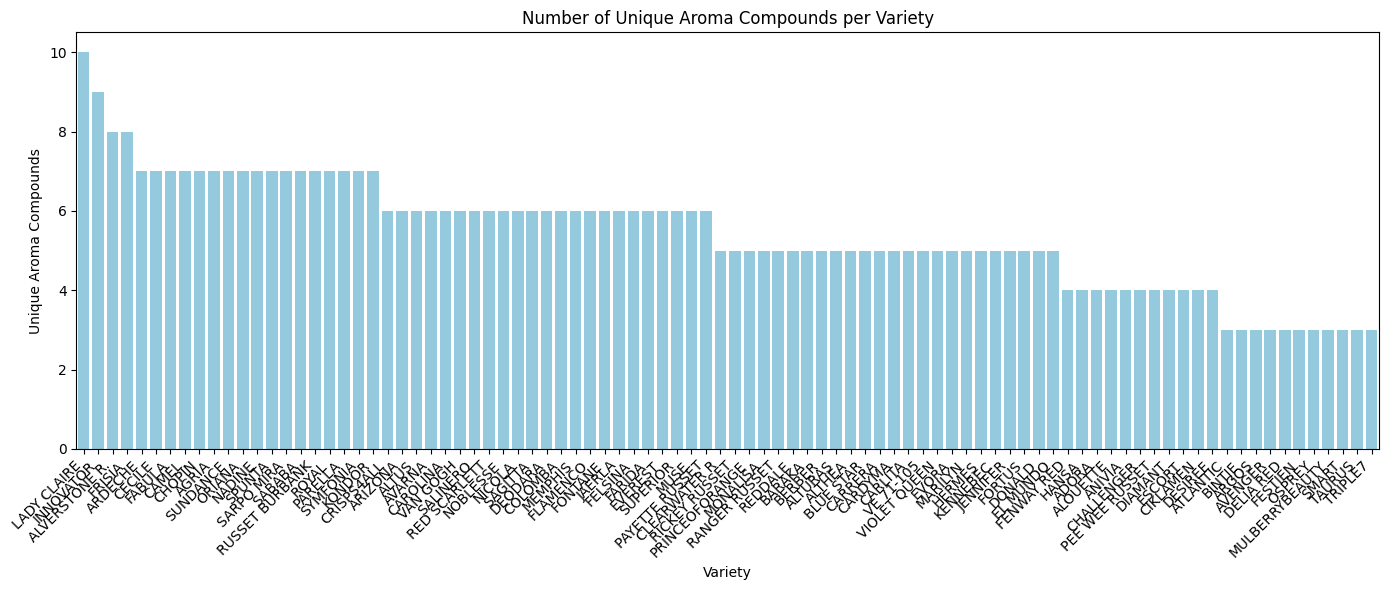

In [8]:
plt.figure(figsize=(14, 6))
sns.barplot(data=aroma_counts_by_variety, x='Variety', y='Aroma Count', color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Number of Unique Aroma Compounds per Variety")
plt.xlabel("Variety")
plt.ylabel("Unique Aroma Compounds")
plt.tight_layout()
plt.show()


# Barplot: Top 20 most common aroma compounds

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_4900\1513164001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=compound_frequency['Frequency'][:20], y=compound_frequency['Compound'][:20], palette='mako')


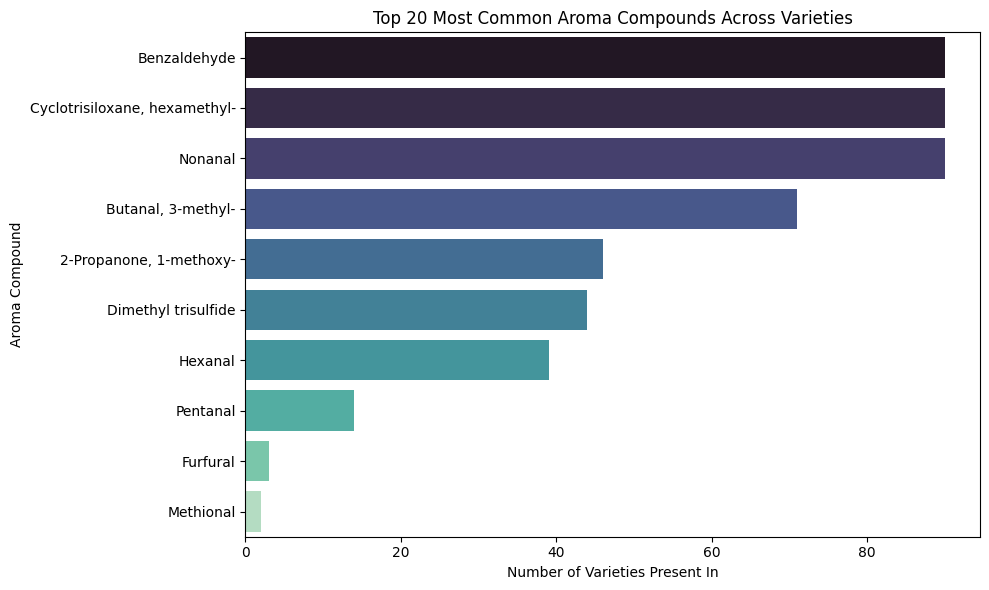

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x=compound_frequency['Frequency'][:20], y=compound_frequency['Compound'][:20], palette='mako')
plt.title("Top 20 Most Common Aroma Compounds Across Varieties")
plt.xlabel("Number of Varieties Present In")
plt.ylabel("Aroma Compound")
plt.tight_layout()
plt.show()


# Heatmap: Variety vs Aroma Compound Presence

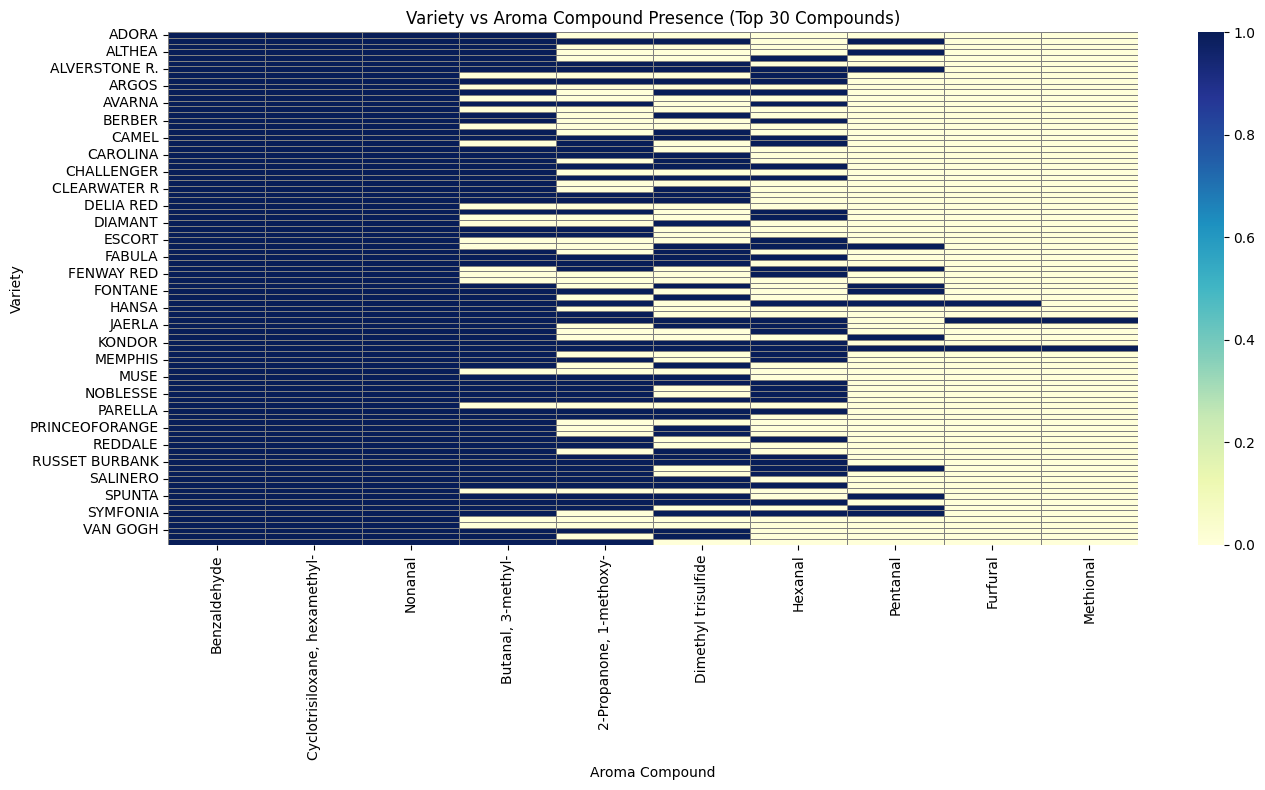

In [10]:
# Focus on top 30 compounds for readability
top30_compounds = compound_frequency['Compound'][:30]
heatmap_data = variety_aroma_matrix[top30_compounds]

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5, linecolor='gray')
plt.title("Variety vs Aroma Compound Presence (Top 30 Compounds)")
plt.xlabel("Aroma Compound")
plt.ylabel("Variety")
plt.tight_layout()
plt.show()


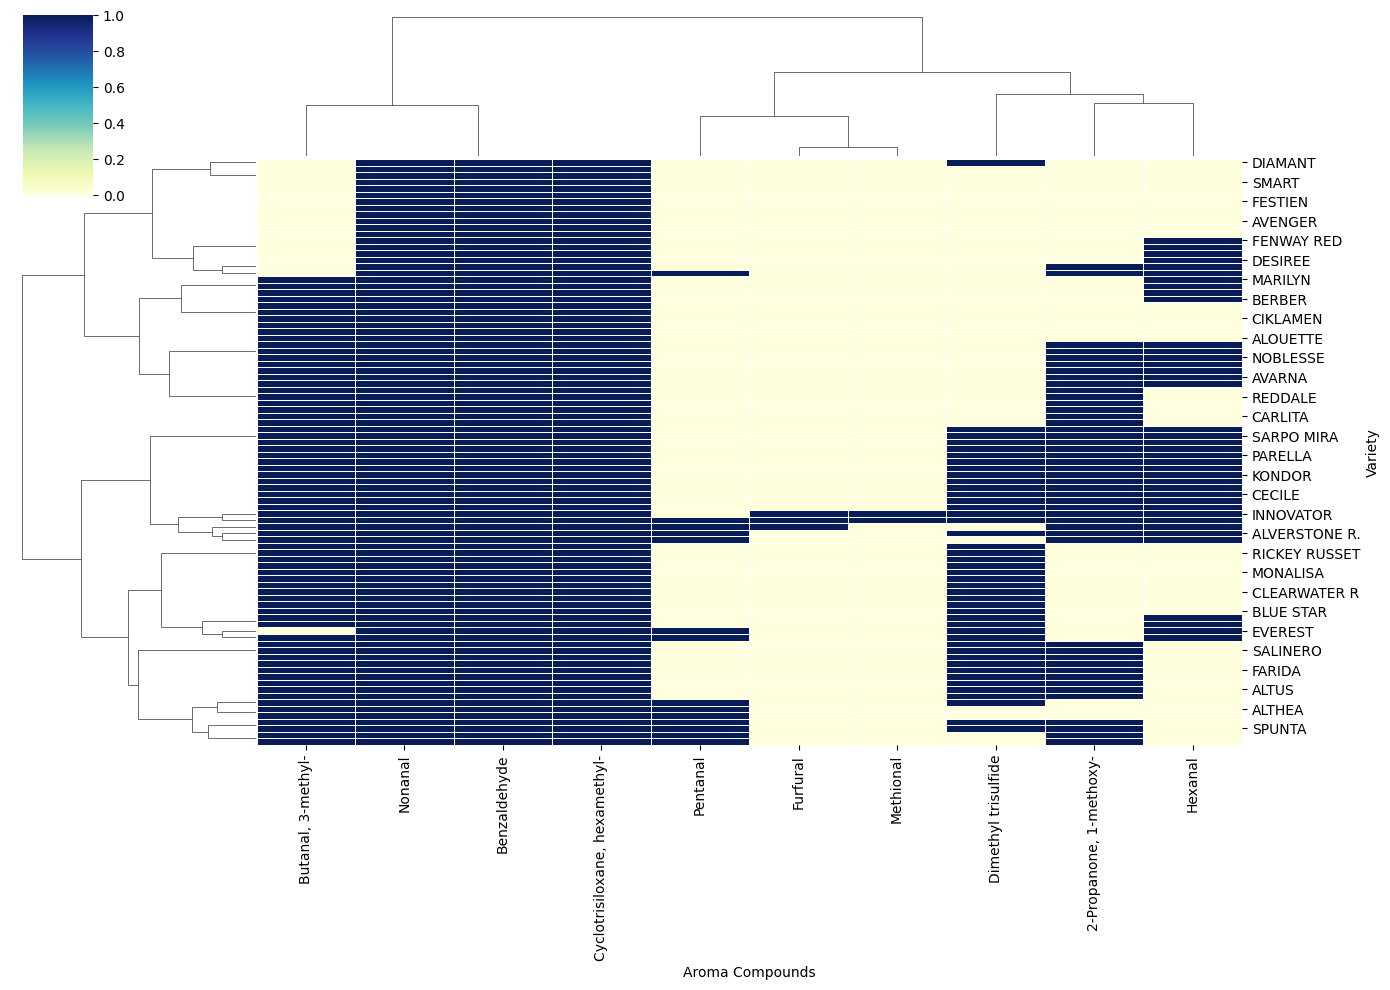

In [11]:
sns.clustermap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    figsize=(14, 10),
    method='ward',
    metric='euclidean'
)


# Compare INNOVATOR vs ALVERSTONE R   as an example to see which compounds are similar and which are diffrent

In [12]:

# Compare two varieties
variety1 = "INNOVATOR"
variety2 = "ALVERSTONE R."

compounds_variety1 = set(exploded.loc[exploded['Variety'] == variety1, 'Aroma Compounds'])
compounds_variety2 = set(exploded.loc[exploded['Variety'] == variety2, 'Aroma Compounds'])

# Find common and unique compounds
common_compounds = compounds_variety1.intersection(compounds_variety2)
unique_variety1 = compounds_variety1 - compounds_variety2
unique_variety2 = compounds_variety2 - compounds_variety1

# Create comparison table
comparison_df = pd.DataFrame({
    "Common Compounds": pd.Series(list(common_compounds)),
    f"Unique to {variety1}": pd.Series(list(unique_variety1)),
    f"Unique to {variety2}": pd.Series(list(unique_variety2))
})
print(comparison_df)

# Save to CSV
comparison_df.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Comparison_INNOVATOR_vs_ALVERSTONE.csv", index=False)
print("Comparison saved as 'Comparison_INNOVATOR_vs_ALVERSTONE.csv'")


                Common Compounds Unique to INNOVATOR Unique to ALVERSTONE R.
0        2-Propanone, 1-methoxy-            Furfural                Pentanal
1             Butanal, 3-methyl-           Methional                     NaN
2  Cyclotrisiloxane, hexamethyl-                 NaN                     NaN
3                        Hexanal                 NaN                     NaN
4                   Benzaldehyde                 NaN                     NaN
5            Dimethyl trisulfide                 NaN                     NaN
6                        Nonanal                 NaN                     NaN
Comparison saved as 'Comparison_INNOVATOR_vs_ALVERSTONE.csv'


# Jaccard Similarity Matrix for All Varieties

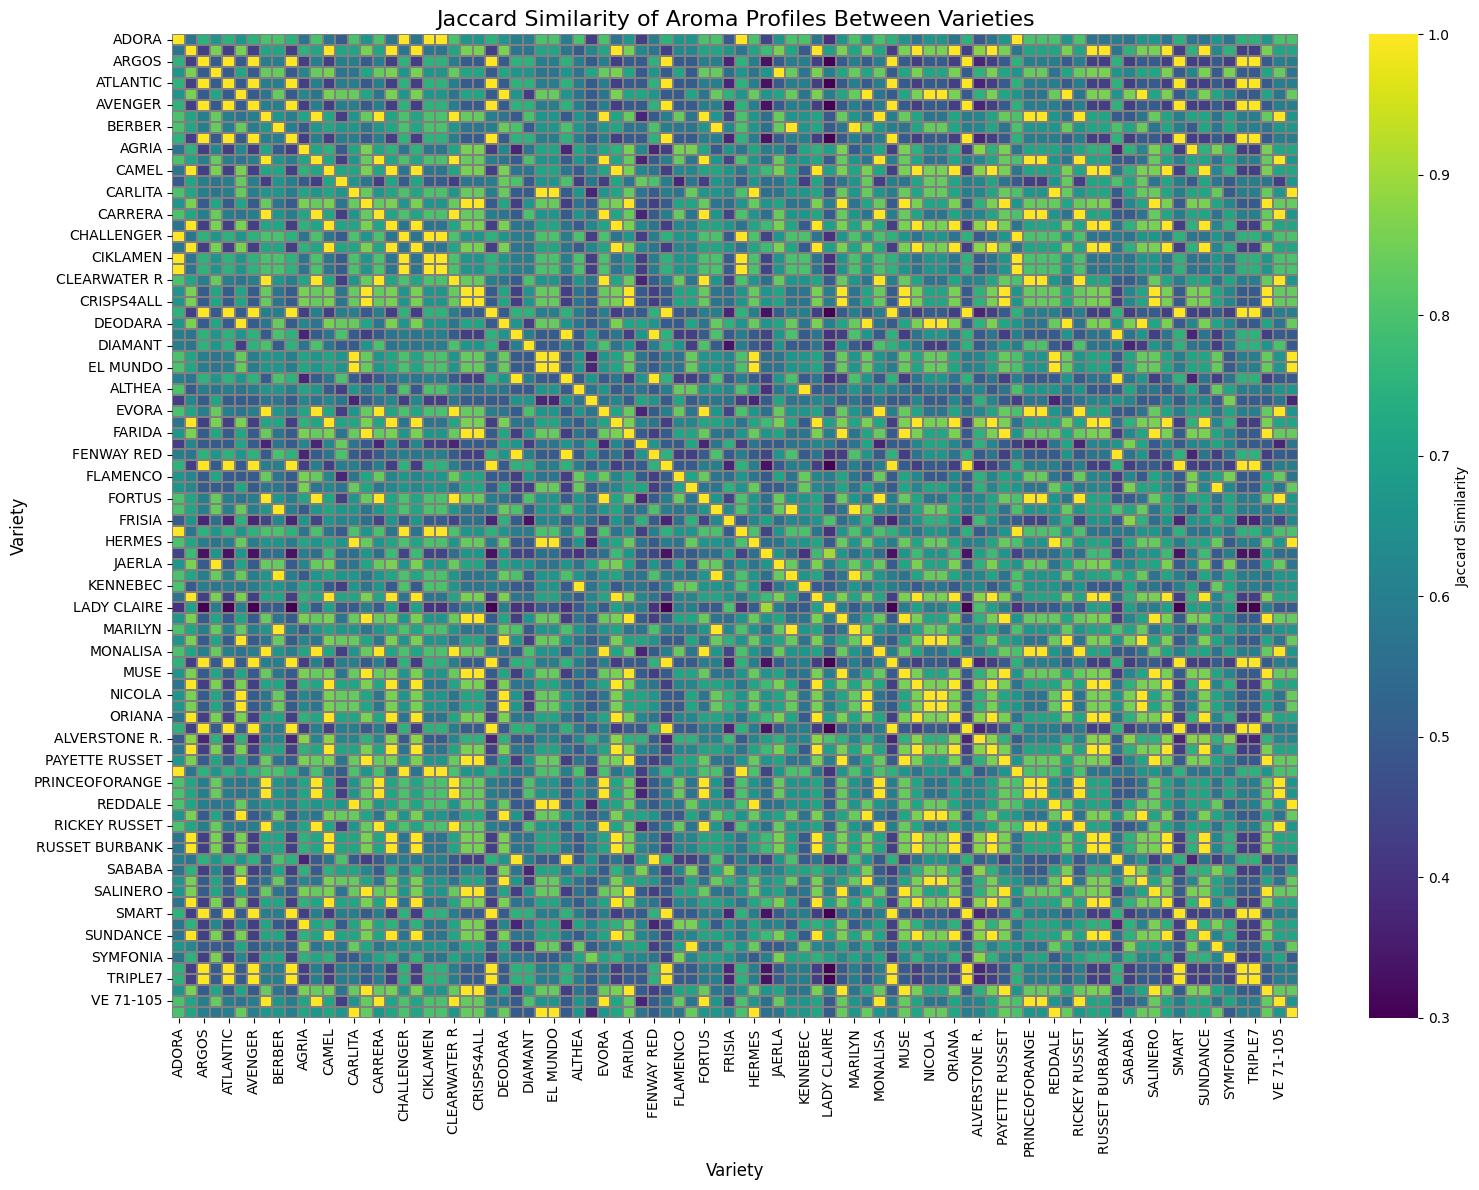

In [13]:
from itertools import combinations

# Build a dictionary: variety -> set of compounds
variety_compounds = {
    v: set(exploded.loc[exploded['Variety'] == v, 'Aroma Compounds'])
    for v in exploded['Variety'].unique()
}

# Compute Jaccard similarity for all pairs
varieties = list(variety_compounds.keys())
jaccard_matrix = pd.DataFrame(index=varieties, columns=varieties, dtype=float)

for v1 in varieties:
    for v2 in varieties:
        set1, set2 = variety_compounds[v1], variety_compounds[v2]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        jaccard_matrix.loc[v1, v2] = intersection / union if union > 0 else 0

# Display matrix
jaccard_matrix = jaccard_matrix.fillna(0)
jaccard_matrix

plt.figure(figsize=(16,12))
sns.heatmap(
    jaccard_matrix.astype(float),
    cmap="viridis",  # Better color range
    cbar_kws={'label': 'Jaccard Similarity'},
    linewidths=0.3,
    linecolor='gray'
)
plt.title("Jaccard Similarity of Aroma Profiles Between Varieties", fontsize=16)
plt.xlabel("Variety", fontsize=12)
plt.ylabel("Variety", fontsize=12)
plt.tight_layout()
plt.show()




# Extract top 5 most similar & most different

In [14]:
# Convert to long format
pairs = []
for i, v1 in enumerate(jaccard_matrix.index):
    for j, v2 in enumerate(jaccard_matrix.columns):
        if i < j:  # avoid duplicates and self-comparisons
            pairs.append((v1, v2, jaccard_matrix.loc[v1, v2]))

pairs_df = pd.DataFrame(pairs, columns=["Variety 1", "Variety 2", "Jaccard Similarity"])

# Top 5 most similar
top5_similar = pairs_df.sort_values(by="Jaccard Similarity", ascending=False).head(5)

# Top 5 most different
top5_different = pairs_df.sort_values(by="Jaccard Similarity", ascending=True).head(5)

# Combine results
top_pairs = pd.concat([
    top5_similar.assign(Type="Most Similar"),
    top5_different.assign(Type="Most Different")
])

top_pairs


,Variety 1,Variety 2,Jaccard Similarity,Type
2934,ALTURAS,MARILYN,1.0,Most Similar
2922,FORTUS,VE 71-105,1.0,Most Similar
17,ADORA,CHALLENGER,1.0,Most Similar
3082,HERMES,REDDALE,1.0,Most Similar
3036,HANSA,PEE WEE RUSSET,1.0,Most Similar
3335,LADY CLAIRE,TRIPLE7,0.3,Most Different
3334,LADY CLAIRE,TAURUS,0.3,Most Different
564,AVENGER,LADY CLAIRE,0.3,Most Different
3329,LADY CLAIRE,SMART,0.3,Most Different
3306,LADY CLAIRE,MULBERRYBEAUTY,0.3,Most Different
